# Milestone 4: Preprocessing, Feature Engineering & Sentiment Trend Analysis

This part of the notebook entails preprocessing the labeled headlines, TF-IDF feature engineering, and sentiment trend analysis + visuals + limitations for Milestone 4.

Before jumping into preprocessing, We will do a proper EDA pass first, since the cleaning decisions below should be justified by what's actually in the data rather than guesses. This also covers the data quality issues we ran into as a group while manually labeling (teaser text glued onto headlines, wire-service prefixes, etc.) - I dig into those with real examples pulled straight from the data.

## Step 1: Load the data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()  # upload final_labeledCSV

df = pd.read_csv(next(iter(uploaded)))
print(df.head())
print("\nColumns:", df.columns.tolist())
print("Total headlines:", len(df))

Saving final_labeled_dataset.csv to final_labeled_dataset (1).csv
            source                                           headline  \
0   Business Daily  KBL returns to court over alleged corruption i...   
1  Citizen Digital  India's Gen Z protesters adapt to internet shu...   
2  Gma News Online  Who is Karim Khan, the barrister at the center...   
3     Kahawa Tungu  Body found dumped along Nairobi–Naivasha Highw...   
4     Kahawa Tungu  Two including Italian killed, two injured in R...   

                         published  \
0    Thu, 23 Jul 2026 13:38:53 GMT   
1              2026-07-24 23:51:00   
2              2026-07-24 22:40:39   
3  Sat, 25 Jul 2026 05:18:51 +0000   
4  Sat, 25 Jul 2026 05:15:51 +0000   

                                                link sentiment  
0  https://www.businessdailyafrica.com/bd/corpora...  negative  
1  https://citizen.digital/article/indias-gen-z-p...  negative  
2  https://www.gmanetwork.com/news/topstories/wor...  negative  
3  htt

In [4]:
df.head()

,source,headline,published,link,sentiment
0,Business Daily,KBL returns to court over alleged corruption i...,"Thu, 23 Jul 2026 13:38:53 GMT",https://www.businessdailyafrica.com/bd/corpora...,negative
1,Citizen Digital,India's Gen Z protesters adapt to internet shu...,2026-07-24 23:51:00,https://citizen.digital/article/indias-gen-z-p...,negative
2,Gma News Online,"Who is Karim Khan, the barrister at the center...",2026-07-24 22:40:39,https://www.gmanetwork.com/news/topstories/wor...,negative
3,Kahawa Tungu,Body found dumped along Nairobi–Naivasha Highw...,"Sat, 25 Jul 2026 05:18:51 +0000",https://kahawatungu.com/body-found-dumped-alon...,negative
4,Kahawa Tungu,"Two including Italian killed, two injured in R...","Sat, 25 Jul 2026 05:15:51 +0000",https://kahawatungu.com/two-including-italian-...,negative


## Step 2: Exploratory Data Analysis (EDA)

Checking size, structure, missing values, and class balance before touching anything.

In [5]:
df.dtypes

,0
source,object
headline,object
published,object
link,object
sentiment,object


In [6]:
df.isna().sum()

,0
source,0
headline,0
published,1297
link,231
sentiment,0


published is missing on over half the rows and link is missing a bit too. Not fixing this now, but keeping it in mind since it'll matter later for anything time-based (that's a Milestone 4 problem though)

In [30]:
missing_pct = df['published'].isna().mean() * 100
print(f"published missing: {missing_pct:.1f}% of rows")

published missing: 51.7% of rows


### Class balance (sentiment)

This matters for later - if one class dominates, TF-IDF features and any downstream model will be biased toward it.

In [8]:
sentiment_counts = df['sentiment'].value_counts()
sentiment_counts

,count
sentiment,
negative,1139
positive,942
neutral,430


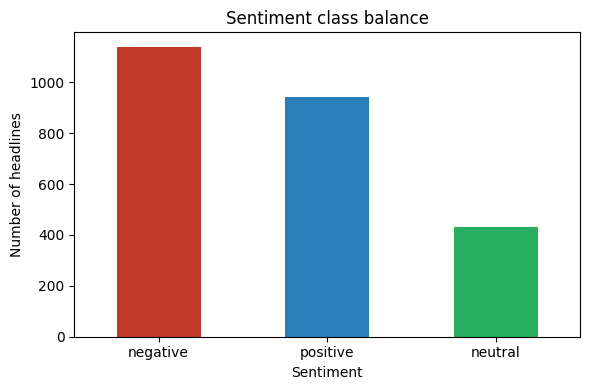

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
sentiment_counts.plot(kind='bar', color=['#c0392b','#2980b9','#27ae60'], ax=ax)
ax.set_title('Sentiment class balance')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of headlines')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Negative is the biggest class (45%), positive close behind (37%), neutral is the smallest by far (17%). Makes sense with what we noticed while manually labeling - that every model we tried (DistilBERT, CardiffNLP, VADER, even our own bootstrap classifier) struggled the most with neutral. Probably because there's just less of it to learn from.

### Source distribution

Checking whether a handful of outlets dominate the dataset, since that could skew sentiment trends by outlet later.

In [10]:
top_sources = df['source'].value_counts().head(15)
top_sources

,count
source,
The Standard,419
The Star,346
NTV Kenya,301
Citizen Digital (via Google News),246
K24,192
World News API,139
Citizen Digital,89
NewsData.io,86
Kenyans.co.ke,80


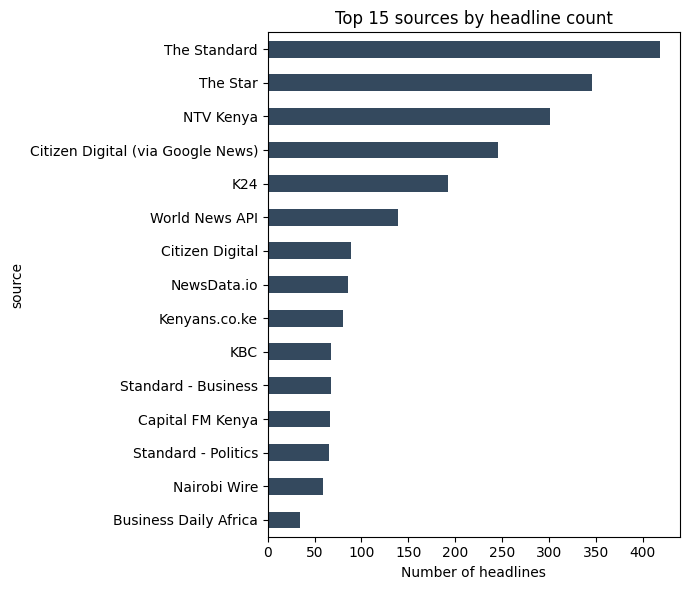

In [11]:
fig, ax = plt.subplots(figsize=(7,6))
top_sources.sort_values().plot(kind='barh', color='#34495e', ax=ax)
ax.set_title('Top 15 sources by headline count')
ax.set_xlabel('Number of headlines')
plt.tight_layout()
plt.show()

The dataset is heavily equipped with headlines from handful of Kenyan outlets - The Standard, The Star, NTV Kenya, and Citizen Digital (counted separately from its "via Google News" duplicate feed) together make up a large share of all headlines. Meanwhile there's a long tail of sources with just 1-2 headlines each (some not even Kenyan - e.g. Jamaica Observer, Medicine Hat News). This matters for the trend-by-outlet analysis later: results for major outlets will be far more reliable than for the long-tail sources.

### Headline length

Just a sanity check on how long these headlines typically are, and whether any are suspiciously short/long (which usually signals a scraping artifact).

In [12]:
df['headline_len_words'] = df['headline'].str.split().str.len()
df['headline_len_words'].describe()

,headline_len_words
count,2511.000000
mean,12.326563
std,6.194787
min,2.000000
25%,9.000000
50%,11.000000
75%,13.000000
max,54.000000


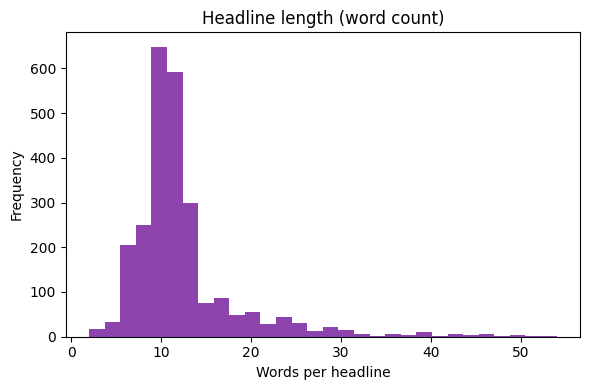

In [13]:
fig, ax = plt.subplots(figsize=(6,4))
df['headline_len_words'].plot(kind='hist', bins=30, color='#8e44ad', ax=ax)
ax.set_title('Headline length (word count)')
ax.set_xlabel('Words per headline')
plt.tight_layout()
plt.show()

Most headlines sit in a reasonable 8-14 word range, but there's a long right tail - some headlines run past 40-50 words. Those are almost certainly the teaser described below, not genuine long headlines.

### Data quality issues found during manual labeling

While labeling the `still_needs_review` batch as a group, we ran into a few recurring issues specific to certain sources. Pulling real examples straight from the data below instead of just describing them, since that's what actually justifies the cleaning steps in Step 3.

**1. Headline + teaser + byline glued together (mainly Citizen Digital)**

Some headlines have a relative timestamp prefix ("News•4 minutes ago"), then the real headline, then a `"By <Author>"` byline, then in some cases even more teaser text run straight into the byline with no spacing.

In [14]:
teaser_examples = df[df['headline'].str.contains(r'ago.*By [A-Z]', regex=True, na=False)]
print(f"{len(teaser_examples)} headlines affected")
for h in teaser_examples['headline'].head(5):
    print('-', h)
    print()

42 headlines affected
- News•4 minutes agoAviation workers issue seven-day strike notice over labour disputesBy Jasmine Wambui

- 4 hours agoMoses Kuria fires back at Gachagua over Ol Kalou violence allegationsBy Kenneth GachieKuria dismissed Gachagua's latest claims linking him to electoral chaos and the hiring of goons during the recently concluded by-elections. The former Ruto adviser...Read More

- 5 hours agoSharon Otieno murder case: Obado, co-accused placed in police custody as bond cancelled after convictionBy Dzuya WalterThe court hence directed that the accused persons be remanded to police custody until after 21 days when the matter shall be mentioned again to confirm compliance with orders.Judge Cecilia Githua had...Read More

- News•7 minutes ago‘Kama wewe ni mwanaume niweke kwa cell!’ Gachagua dares Murkomen to arrest him over Mungiki claimsBy Joseph Muia

- 4 hours agoTension in Embu after preacher prophesies death of threeBy Anthony NdwigaApostle John Robert of Power of

**2. Wire-service country prefixes (e.g. "Kenya: ...", "Uganda: ...")**

A smaller set of headlines - mostly from AllAfrica-style wire feeds - are prefixed with a country/region name and colon before the actual headline starts. Important: this is *not* the same as a headline that happens to start with a person's name and colon (e.g. "Ruto: No defence for goons..." or "Kanjama: Lawyers can strike..." are legitimate headline style, not artifacts) - so any cleaning needs to target specific country names, not any capitalized word followed by a colon.

In [15]:
country_prefixes = ['Kenya', 'Uganda', 'Tanzania', 'Africa', 'Rwanda', 'Burundi', 'Ethiopia', 'Somalia', 'Nigeria', 'Ghana', 'Zambia', 'Zimbabwe']
import re
prefix_pattern = r'^(' + '|'.join(country_prefixes) + r'):\s*'
wire_examples = df[df['headline'].str.contains(prefix_pattern, regex=True, na=False)]
print(f"{len(wire_examples)} headlines affected")
for h in wire_examples['headline'].head(5):
    print('-', h)

17 headlines affected
- Kenya: Isiolo Businesswoman Shot Dead in Suspected Targeted Attack As Governor Demands Swift Probe
- Uganda: AFCON 2027 - A Golden Opportunity for Ugandans to Serve, Earn and Showcase the Nation
- Africa: Over $1.6m and Counting - How Betpawa's Model Is Improving Athlete Payment in Africa
- Kenya: Employer-Led Training Delivers Returns, Boosts SME Productivity
- Uganda: Here Comes the Mandatory Monthly National Cleaning Days


/tmp/ipykernel_3374/2657327670.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  wire_examples = df[df['headline'].str.contains(prefix_pattern, regex=True, na=False)]


**3. Duplicate headlines**

Just as a counter measure to make sure there's no redundancy - we already handled duplicate removal during data collection/merging (Milestone 1), so this should come back at 0.

In [16]:
dupe_count = df['headline'].duplicated().sum()
print(f"{dupe_count} duplicate headline(s) found")
df[df['headline'].duplicated(keep=False)].sort_values('headline')[['source','headline','sentiment']]

0 duplicate headline(s) found


,source,headline,sentiment


**4. Non-Kenyan/off-topic headlines mixed in**

Since the RSS collection pulled from broad feeds, a handful of headlines are clearly not Kenyan news at all (Brazil tariffs, Ann Widdecombe in the UK, Jamaica Observer content). These slipped through because they came from generic international wire APIs rather than Kenyan outlets specifically. I'm noting this here as a known limitation rather than trying to filter it out completely - a handful of off-topic headlines by source name alone risks false positives (e.g. a Kenyan outlet covering an international story is legitimate), and manually confirming topic relevance for every row was outside the group's timeframe.

## Step 3: Preprocessing

Based on the EDA above, here's the cleaning plan, in order:

1. Strip wire-service country prefixes ("Kenya: ", "Uganda: ", etc.)
2. Strip the teaser/timestamp/byline junk glued onto some headlines
3. Drop duplicate headlines (re-checked after the two steps above, since cleaning can reveal duplicates that weren't obvious in the raw text)
4. Standard NLP cleaning for the TF-IDF step: lowercase, remove punctuation/numbers, tokenize, remove stopwords, lemmatize

Keeping the original `headline` column untouched and building `clean_headline` alongside it, so nothing is destructively overwritten.

In [17]:
def strip_wire_prefix(headline: str) -> str:
    """Remove a leading 'Country: ' wire-service dateline, if present."""
    return re.sub(prefix_pattern, '', headline)


def strip_teaser_junk(headline: str) -> str:
    """Remove a leading relative-time stamp ('News*4 minutes ago') and cut off
    anything from a 'By <Author>' byline onward."""
    headline = re.sub(r'^(?:[A-Za-z]+\s*[•\-]\s*)?\d+\s*(?:minute|hour|day)s?\s*ago', '', headline)
    headline = re.split(r'By [A-Z][a-zA-Z]+(?:\s[A-Z][a-zA-Z]+)?', headline)[0]
    return headline.strip()

In [18]:
df['clean_headline'] = df['headline'].apply(strip_wire_prefix).apply(strip_teaser_junk)

# spot-check: show a few before/after pairs for the rows we know were affected
check_rows = pd.concat([teaser_examples.head(3), wire_examples.head(3)])
df.loc[check_rows.index, ['headline', 'clean_headline']]

,headline,clean_headline
178,News•4 minutes agoAviation workers issue seven...,Aviation workers issue seven-day strike notice...
179,4 hours agoMoses Kuria fires back at Gachagua ...,Moses Kuria fires back at Gachagua over Ol Kal...
180,"5 hours agoSharon Otieno murder case: Obado, c...","Sharon Otieno murder case: Obado, co-accused p..."
261,Kenya: Isiolo Businesswoman Shot Dead in Suspe...,Isiolo Businesswoman Shot Dead in Suspected Ta...
278,Uganda: AFCON 2027 - A Golden Opportunity for ...,AFCON 2027 - A Golden Opportunity for Ugandans...
520,Africa: Over $1.6m and Counting - How Betpawa'...,Over $1.6m and Counting - How Betpawa's Model ...


In [19]:
# re-check for duplicates now that junk text has been stripped off
new_dupes = df['clean_headline'].duplicated().sum()
print(f"duplicates after cleaning: {new_dupes}")

df = df.drop_duplicates(subset='clean_headline').reset_index(drop=True)
df.shape

duplicates after cleaning: 1


(2510, 7)

### Standard NLP cleaning

This entails tokenizing, converting to lowercase , removal of stopwords/punctuation  and lemmatization.

In [20]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)          # strip punctuation/numbers
    tokens = nltk.word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

In [21]:
df['clean_headline_nlp'] = df['clean_headline'].apply(clean_text)
df[['headline', 'clean_headline', 'clean_headline_nlp']].head(8)

,headline,clean_headline,clean_headline_nlp
0,KBL returns to court over alleged corruption i...,KBL returns to court over alleged corruption i...,kbl return court alleged corruption sh bn arbi...
1,India's Gen Z protesters adapt to internet shu...,India's Gen Z protesters adapt to internet shu...,india gen protester adapt internet shutdown
2,"Who is Karim Khan, the barrister at the center...","Who is Karim Khan, the barrister at the center...",karim khan barrister center icc internal crisis
3,Body found dumped along Nairobi–Naivasha Highw...,Body found dumped along Nairobi–Naivasha Highw...,body found dumped along nairobi naivasha highw...
4,"Two including Italian killed, two injured in R...","Two including Italian killed, two injured in R...",two including italian killed two injured rabai...
5,Archbishop Ole Sapit Challenges Ruto: Stop War...,Archbishop Ole Sapit Challenges Ruto: Stop War...,archbishop ole sapit challenge ruto stop warni...
6,NTSA Arrests 45 Pedestrians for Skipping Nyayo...,NTSA Arrests 45 Pedestrians for Skipping Nyayo...,ntsa arrest pedestrian skipping nyayo stadium ...
7,DCI arrests director in claimed Qatar job scam...,DCI arrests director in claimed Qatar job scam...,dci arrest director claimed qatar job scam ken...


Quick check: does removing stopwords/lemmatizing ever leave a headline empty? That would be a problem for TF-IDF (an all-zero row).

In [22]:
empty_after_cleaning = (df['clean_headline_nlp'].str.strip() == '').sum()
print(f"rows empty after NLP cleaning: {empty_after_cleaning}")

rows empty after NLP cleaning: 0


## Step 4: TF-IDF Feature Engineering

Using TF-IDF (Term Frequency-Inverse Document Frequency) on the cleaned headlines, same reasoning as the class activity: it downweights common words that survived stopword removal and upweights words that are more distinctive to a specific headline.

Using unigrams + bigrams (`ngram_range=(1,2)`) since a lot of sentiment signal in headlines comes from short phrases ("court boycott", "arrest warrant") rather than single words.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = tfidf.fit_transform(df['clean_headline_nlp'])
y = df['sentiment'].values

X.shape

(2510, 5000)

Checking what the top TF-IDF terms actually look like, as a sanity check that the vectorizer is picking up meaningful vocabulary and not junk tokens.

In [24]:
feature_names = tfidf.get_feature_names_out()
avg_tfidf = X.mean(axis=0).A1
top_terms = pd.Series(avg_tfidf, index=feature_names).sort_values(ascending=False).head(20)
top_terms

,0
kenya,0.019543
digital,0.016537
citizen,0.015599
citizen digital,0.015192
ruto,0.012127
world,0.010649
cup,0.009383
new,0.009198
ol,0.009192
kalou,0.009144


In [31]:
citizen_leak = df[df['clean_headline'].str.contains('Citizen Digital', case=False, na=False)]
print(f"{len(citizen_leak)} headlines contain 'Citizen Digital' in the text")
for h in citizen_leak['clean_headline'].head(5):
    print('-', h)

231 headlines contain 'Citizen Digital' in the text
- Venezuela earthquake death toll now at 5,208 - Citizen Digital
- Four arrested for allegedly stealing toddler in Embakasi, baby rescued - Citizen Digital
- Twin killed, brother injured in Kamandura road construction accident - Citizen Digital
- Murkomen hits back at Gachagua over police rape claims in Ol Kalou - Citizen Digital
- 'Niko Kadi' mobilizer Allans Ademba arrested in Ol Kalou - Citizen Digital


In [33]:
def strip_source_suffix(headline: str) -> str:
    """Remove a trailing ' - <Source Name>' attribution, if present."""
    return re.sub(r'\s*-\s*(Citizen Digital|The Standard|The Star|NTV Kenya|K24|KBC)\s*$', '', headline)

In [34]:
before_count = df['clean_headline'].str.contains(' - Citizen Digital', case=False, na=False).sum()
df['clean_headline'] = df['clean_headline'].apply(strip_source_suffix)
after_count = df['clean_headline'].str.contains(' - Citizen Digital', case=False, na=False).sum()
print(f"before: {before_count}, after: {after_count}")

before: 231, after: 0


In [35]:
#redoing the NLP cleaning + TF-IDF steps since `clean_headline` changed
df['clean_headline_nlp'] = df['clean_headline'].apply(clean_text)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = tfidf.fit_transform(df['clean_headline_nlp'])
y = df['sentiment'].values

feature_names = tfidf.get_feature_names_out()
avg_tfidf = X.mean(axis=0).A1
top_terms = pd.Series(avg_tfidf, index=feature_names).sort_values(ascending=False).head(20)
top_terms

,0
kenya,0.019568
ruto,0.012187
world,0.010723
cup,0.009456
ol,0.009420
kalou,0.009372
ol kalou,0.009372
new,0.009177
nairobi,0.008542
world cup,0.008505


Noticed citizen and citizen digital showed up near the top of the list, which doesn't make sense for sentiment - that's the source name leaking into the actual headline text, not real content. Went and checked it properly.Confirmed, 231 headlines had " - Citizen Digital" stuck on the end as a suffix. This is a 4th data quality issue we didn't catch during manual labeling - only found it because the TF-IDF output looked off.Resolved this and now it's actual Kenyan news vocab.